# Indicator selection based on best price predictor

This notebook features a serie of experiments that use the `stocks_daily` data model with all of its indicators to estimate which indicators best correlate with price movement.

First thing first a simple check on all of the indicators taken together, than the same check fixed on one single indicator to see what is the best time window for the given indicator, finally an extra test with all indicators, but only with the best performing time window fixed.

##### Set up and helper code

In [5]:
# imports
import sys

sys.path.append("../..")

from datetime import date
import polars as pl
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from scipy.stats import spearmanr

from analysis.utils import *
from etl.transformation.gold.stocks_ml_ready import (
    StocksMlReadyGold,
    append_future_returns,
)


In [6]:
# notebook parameters
DATAPLATFORM_ROOT = "../../dataplatform"
# 1 week price lookahead
TRADING_DAYS_LOOKAHEAD = 5
START_DATE = date(2022, 1, 1)
END_DATE = date(2023, 1, 1)

In [7]:
lf = StocksMlReadyGold(
    [
        append_future_returns(
            lookahead_steps=TRADING_DAYS_LOOKAHEAD,
            price_column="open",
            future_price_col="future_price",
        )
    ],
    dataplatform_root=DATAPLATFORM_ROOT,
).build()
stocks_daily = lf.filter(
    (pl.col("timeframe") >= START_DATE) & (pl.col("timeframe") <= END_DATE)
    # volatility_1_steps_1d and sharpe_1_steps_1d are always null (a 1-day window
    # can't produce a sample std dev), so imputing them would be meaningless.
    # strict=False: not every caller's column subset includes these two.
).drop(["embedding", "volatility_1_steps_1d", "sharpe_1_steps_1d"]).collect()
stocks_daily = stocks_daily.drop(["month", "year", "overbought", "oversold"])
print(f"{stocks_daily.shape[1]} features across {stocks_daily.shape[0]} rows")
stocks_daily.head()


[23:25:34] Building from source data model gold.stocks_ml_ready
[23:25:34] gold.stocks_ml_ready build plan ready and validated


/tmp/ipykernel_71847/4051651812.py:16: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  ).drop(["embedding", "volatility_1_steps_1d", "sharpe_1_steps_1d"]).collect()


56 features across 597943 rows


timeframe,symbol,open,close,high,low,volume,log_return_1d,log_return_1w,log_return_1m,log_return_30_steps,log_return_1q,log_return_6m,log_return_1y,return_1d,return_1w,return_1m,return_30_steps,return_1q,return_6m,return_1y,open_rolling_1_steps_1d,open_rolling_1w,open_rolling_1m,open_rolling_30_steps,open_rolling_1q,open_rolling_6m,open_rolling_1y,volatility_1w,volatility_1m,volatility_30_steps,volatility_1q,volatility_6m,volatility_1y,sharpe_1w,sharpe_1m,sharpe_30_steps,sharpe_1q,sharpe_6m,sharpe_1y,rsi,rsi_1d,rsi_1w,rsi_1m,rsi_30_steps,rsi_1q,rsi_6m,rsi_1y,shares_outstanding,estimated_float_shares,earnings,evaluation,price_to_earnings,float_adjusted_market_cap,earnings_per_share,future_price
date,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,i128,f64,f64,f64,f64,f64
2022-01-03,"""A""",154.77308,152.320068,155.201385,149.837856,1.6063e6,-0.018739,-0.013023,0.048086,-0.034339,0.023611,0.051677,0.282229,-0.018565,-0.012939,0.049261,-0.033756,0.023891,0.053036,0.326083,154.77308,155.5765,151.172319,150.950521,151.685044,154.554243,140.560473,0.010844,0.014378,0.016732,0.014305,0.013001,0.013101,-1.193181,3.426148,-2.017483,1.670099,4.079215,24.889065,50.743925,0.0,33.78666,59.945014,45.610616,51.682918,52.038286,55.360373,302000797,2.3799e8,1210000000,4.6742e10,38.629416,3.6835e10,4.006612,139.480683
2022-01-04,"""A""",151.356374,147.170685,151.492652,145.72029,2.234e6,-0.034391,-0.050182,-0.000534,-0.081841,-0.014823,0.013869,0.239696,-0.033806,-0.048944,-0.000534,-0.078581,-0.014714,0.013965,0.270862,151.356374,154.801672,151.481205,150.713475,151.734354,154.602779,140.705896,0.017144,0.01626,0.017563,0.014962,0.013363,0.013283,-2.854804,-0.032839,-4.474183,-0.983449,1.045087,20.391127,49.107871,0.0,15.191297,49.899252,40.145991,49.002292,50.525557,54.43557,302000797,2.3799e8,1210000000,4.5710e10,37.776649,3.6022e10,4.006612,141.145253
2022-01-05,"""A""",146.820233,144.649521,149.02989,144.581375,2.3705e6,-0.017279,-0.076654,-0.033079,-0.089826,-0.042913,0.001014,0.195363,-0.017131,-0.073789,-0.032538,-0.085909,-0.042006,0.001015,0.215752,146.820233,153.090452,151.393161,150.260739,151.671144,154.627027,140.832512,0.0134,0.016278,0.017726,0.015047,0.013446,0.01323,-5.506547,-1.998882,-4.846535,-2.791666,0.075452,16.308152,40.037173,0.0,1.868209,43.80722,39.498773,47.144089,50.037645,53.636723,302000797,2.3799e8,1210000000,4.4340e10,36.644485,3.4942e10,4.006612,143.870822
2022-01-06,"""A""",144.892904,145.155716,145.973396,141.709832,2.2983e6,0.003493,-0.074591,-0.045773,-0.035937,-0.0209,-0.003523,0.172595,0.003499,-0.071877,-0.044742,-0.035299,-0.020683,-0.003517,0.188385,144.892904,150.744891,151.115426,150.038965,151.559287,154.625036,140.92981,0.014061,0.015786,0.015325,0.014878,0.013431,0.013132,-5.111933,-2.83432,-2.303421,-1.390202,-0.261844,14.345082,46.994942,100.0,4.130923,40.897355,45.378051,48.590826,49.86801,53.284666,302000797,2.3799e8,1210000000,4.3758e10,36.163448,3.4483e10,4.006612,145.486691
2022-01-07,"""A""",145.155705,141.291245,145.749489,141.232842,2.0586e6,-0.026984,-0.0939,-0.061822,-0.051158,-0.031685,-0.027035,0.138503,-0.026623,-0.089626,-0.05995,-0.049871,-0.031188,-0.026673,0.148553,145.155705,148.599659,150.766255,149.894973,151.525206,154.616193,141.019853,0.014225,0.016633,0.015927,0.015127,0.013641,0.013241,-6.300778,-3.604167,-3.131314,-2.061681,-1.955373,11.219104,39.160567,0.0,3.39216,38.610508,43.774449,47.937405,49.019377,52.586537,302000797,2.3799e8,1210000000,4.3837e10,36.22904,3.4546e10,4.006612,140.210755


##### Feature selection code

In [8]:
def normalize_causal(df: pl.DataFrame, cols: list[str], group_col: str = "symbol", order_col: str = "timeframe") -> pl.DataFrame:
    """Z-score normalizes `cols` using only each row's own past.

    For every row, the mean/std used for normalization are computed from that
    row's `group_col` group, restricted to rows with `order_col` <= the row's own
    value (an expanding window that includes the row itself). This guarantees no
    row is ever normalized using data from a later `order_col` value — critical to
    avoid lookahead leakage when these features feed a forecasting model.

    Rows with fewer than 2 observations so far, or zero variance so far (no signal
    yet to normalize against), are left at 0. Nulls are excluded from the running
    mean/std and stay null in the output (unaffected by this function)."""
    df = df.sort([group_col, order_col])
    exprs = []
    for c in cols:
        col = pl.col(c)
        n = col.is_not_null().cum_sum().over(group_col)
        s1 = col.fill_null(0.0).cum_sum().over(group_col)
        s2 = (col.fill_null(0.0) ** 2).cum_sum().over(group_col)
        mean = s1 / n
        var = (s2 - n * mean**2) / (n - 1)
        std = var.sqrt()
        exprs.append(
            pl.when(col.is_not_null() & (n > 1) & (std > 0))
            .then((col - mean) / std)
            .otherwise(0.0)
            .alias(c)
        )
    return df.with_columns(exprs)


def lasso_feature_selection(df: pl.DataFrame):
    """Performs feature selection using a Lasso regressor from scikit learn.
    Expects the input dataframe to contain `timeframe` and `symbol` columns,
    and a `future_price` column, with the rest being numerical columns that
    are being tested for correlation with future price.
    
    Resulting features with highest magnitude weights are deemed the best
    price predictor, while features with 0 weights are deemed unhelpful."""


    feature_cols = [
        c for c in df.columns 
        if c not in ("timeframe", "symbol", "future_price", "price_movement_class")
    ]
    df = normalize_causal(df, feature_cols)
    df = df.select(feature_cols + ["future_price"]).drop_nulls(subset=["future_price"])
    print(f"Selecting over features {feature_cols}")

    x = df.select(feature_cols).to_numpy()
    # TODO: LOOKAHEAD!!!
    # x = SimpleImputer(strategy="median").fit_transform(x)
    y = df["future_price"].to_numpy()

    mask = ~np.isnan(x).any(axis=1)          # drop rows w/ nulls instead of imputing
    x, y = x[mask], y[mask]
    print(x.shape)

    model = Lasso(copy_X=False) # avoid making an extra copy of X
    model.fit(x, y)

    weights = pl.DataFrame({"feature": feature_cols, "weight": model.coef_})
    return weights.sort(pl.col("weight").abs(), descending=True)


def spearman_feature_selection(df: pl.DataFrame):
    feature_cols = [c for c in df.columns
                    if c not in ("timeframe", "symbol", "future_price", "price_movement_class")]
    df = normalize_causal(df, feature_cols)
    df = df.select(feature_cols + ["future_price"]).drop_nulls(subset=["future_price"])

    x = df.select(feature_cols).to_numpy()
    y = df["future_price"].to_numpy()
    mask = ~np.isnan(x).any(axis=1)          # drop rows w/ nulls instead of imputing
    x, y = x[mask], y[mask]

    # Spearman: signed, catches any *monotonic* non-linear relationship
    rho = np.array([spearmanr(x[:, i], y).statistic for i in range(x.shape[1])])
    # Mutual information: unsigned, catches *arbitrary* dependence
    mi = mutual_info_regression(x, y, random_state=0)

    return pl.DataFrame({
        "feature": feature_cols,
        "weight": rho,
        "mi": mi,
        "mi_signed": mi * np.sign(rho),
    }).sort(pl.col("mi").abs(), descending=True)



##### visualization code

In [9]:
def plot_feature_weights(weights: pl.DataFrame, top_n: int = 30, title: str = "Lasso feature weights"):
    """Horizontal bar chart of the top `top_n` features by absolute weight.
    Expects a dataframe with `feature` and `weight` columns, as returned by
    `lasso_feature_selection`. Bars are colored by sign: blue for features that
    correlate with higher future price, red for lower."""
    top = weights.head(top_n).sort("weight")  # ascending so largest magnitude bars end up on top
    colors = ["tab:red" if w < 0 else "tab:blue" for w in top["weight"]]

    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(top))))
    ax.barh(top["feature"], top["weight"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("weight")
    ax.set_title(title)
    fig.tight_layout()
    # return fig

# Using Lasso regression

## All features prediction

This section includes the first version of this experiment where all of the indicators, across all time horizons are tested together against one another.

Here, we simply take the `stocks_daily` data model with future price and do feature selection with the full feature set.

Selecting over features ['open', 'close', 'high', 'low', 'volume', 'log_return_1d', 'log_return_1w', 'log_return_1m', 'log_return_30_steps', 'log_return_1q', 'log_return_6m', 'log_return_1y', 'return_1d', 'return_1w', 'return_1m', 'return_30_steps', 'return_1q', 'return_6m', 'return_1y', 'open_rolling_1_steps_1d', 'open_rolling_1w', 'open_rolling_1m', 'open_rolling_30_steps', 'open_rolling_1q', 'open_rolling_6m', 'open_rolling_1y', 'volatility_1w', 'volatility_1m', 'volatility_30_steps', 'volatility_1q', 'volatility_6m', 'volatility_1y', 'sharpe_1w', 'sharpe_1m', 'sharpe_30_steps', 'sharpe_1q', 'sharpe_6m', 'sharpe_1y', 'rsi', 'rsi_1d', 'rsi_1w', 'rsi_1m', 'rsi_30_steps', 'rsi_1q', 'rsi_6m', 'rsi_1y', 'shares_outstanding', 'estimated_float_shares', 'earnings', 'evaluation', 'price_to_earnings', 'float_adjusted_market_cap', 'earnings_per_share']
(135001, 53)


/home/danie/codice/zecca/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.499006e+30, tolerance: 7.071e+26
  model = cd_fast.enet_coordinate_descent(


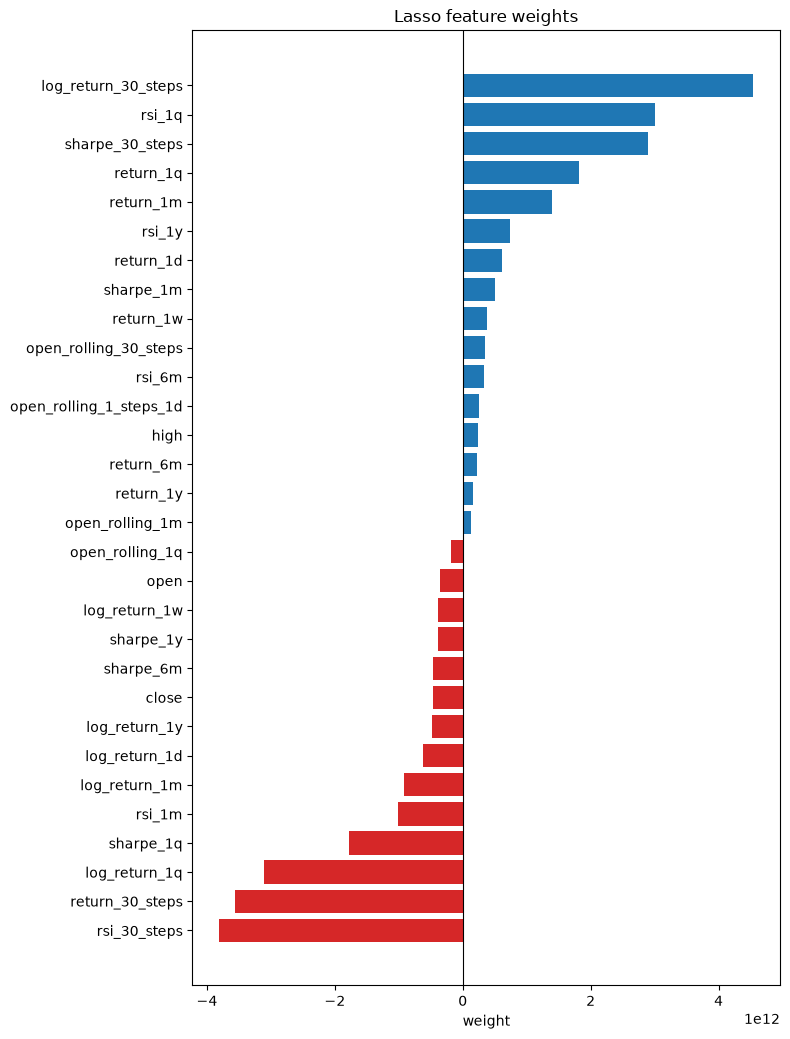

In [24]:
wights = lasso_feature_selection(stocks_daily)
plot_feature_weights(wights)

## Per-indicator time window selection

In this section we fix one indicator at a time and do the same feature selection from before restricting features only to all of the available time windows of each indicator.

Selecting over features ['volatility_1w', 'volatility_1m', 'volatility_30_steps', 'volatility_1q', 'volatility_6m', 'volatility_1y']
(596824, 6)
Selecting over features ['return_1d', 'return_1w', 'return_1m', 'return_30_steps', 'return_1q', 'return_6m', 'return_1y']
(597673, 7)
Selecting over features ['log_return_1d', 'log_return_1w', 'log_return_1m', 'log_return_30_steps', 'log_return_1q', 'log_return_6m', 'log_return_1y']
(597665, 7)
Selecting over features ['rsi_1d', 'rsi_1w', 'rsi_1m', 'rsi_30_steps', 'rsi_1q', 'rsi_6m', 'rsi_1y']
(305492, 7)
Selecting over features ['open_rolling_1_steps_1d', 'open_rolling_1w', 'open_rolling_1m', 'open_rolling_30_steps', 'open_rolling_1q', 'open_rolling_6m', 'open_rolling_1y']
(597562, 7)
Selecting over features ['sharpe_1w', 'sharpe_1m', 'sharpe_30_steps', 'sharpe_1q', 'sharpe_6m', 'sharpe_1y']
(597447, 6)


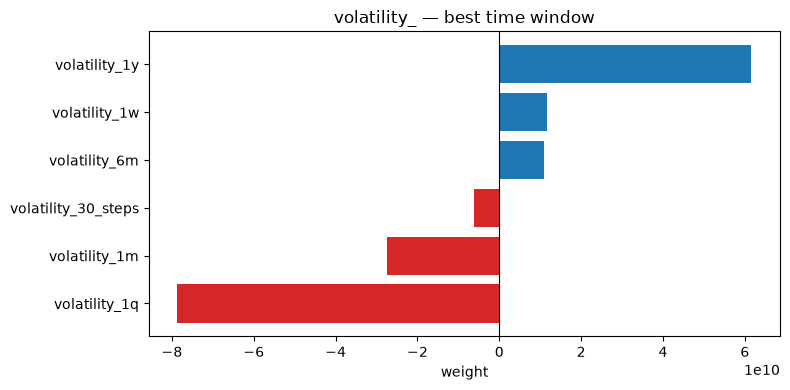

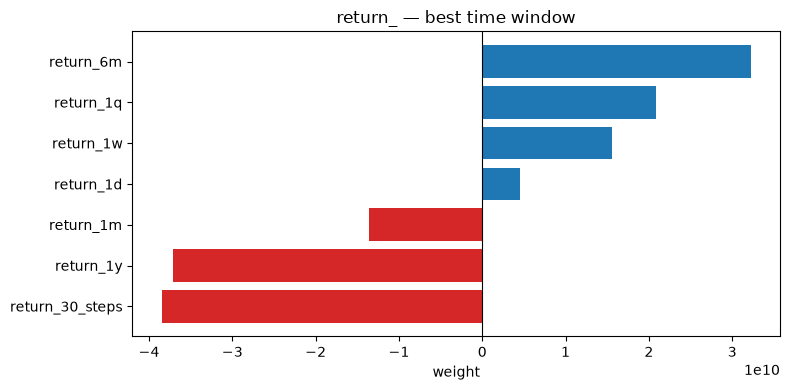

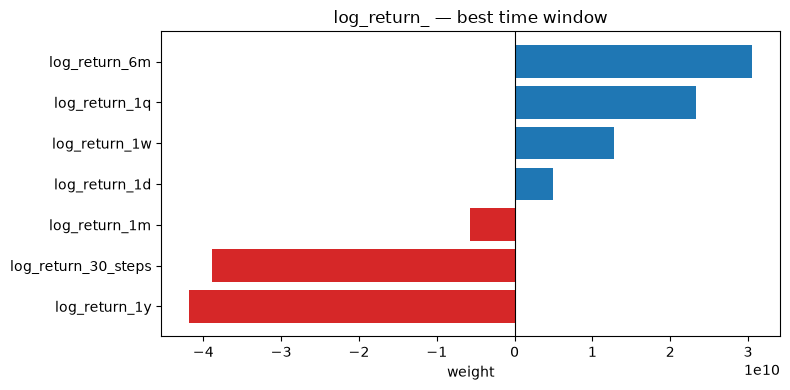

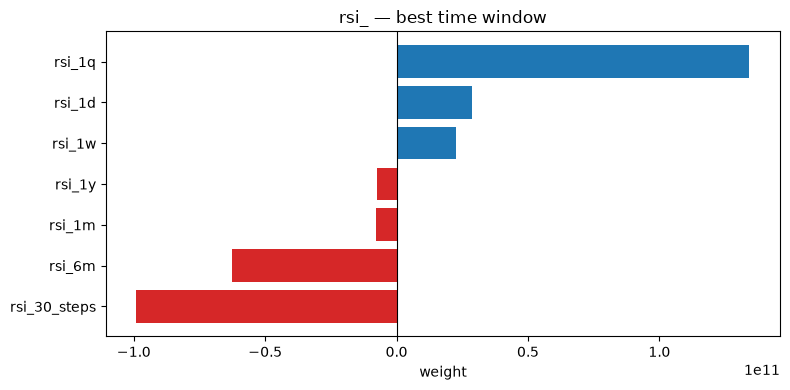

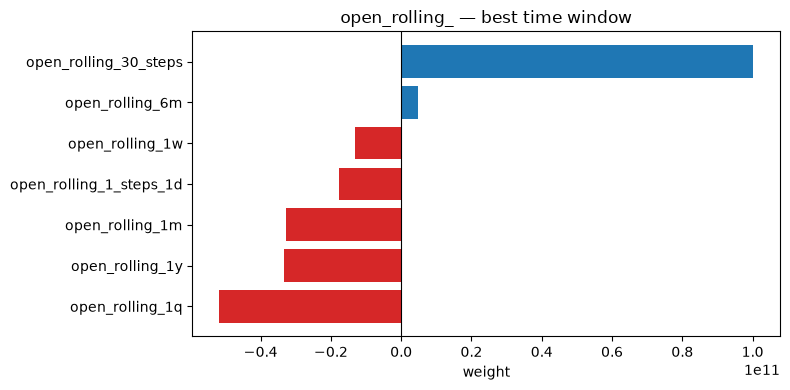

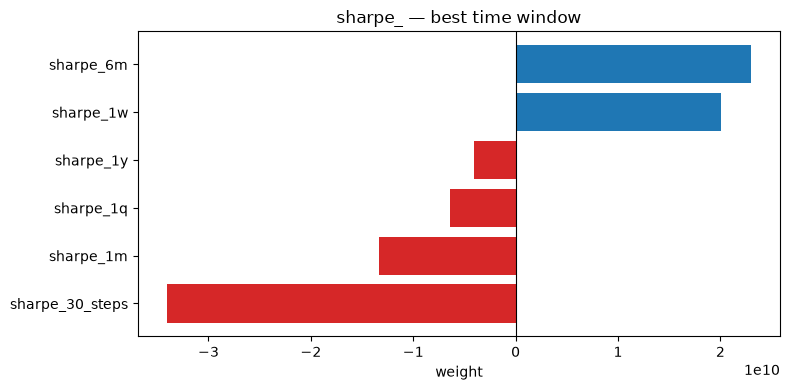

In [25]:
INDICATOR_PREFIX = [
    "volatility_",
    "return_",
    "log_return_",
    "rsi_",
    "open_rolling_",
    "sharpe_",
]

for prefix in INDICATOR_PREFIX:
    # select columns matching the prefix + the future price
    indicator_cols = [c for c in stocks_daily.columns if c.startswith(prefix)]
    subset = stocks_daily.select(["symbol", "timeframe"] + indicator_cols + ["future_price"])

    # run the same feature selection above with the selected dataframe
    weights = lasso_feature_selection(subset)
    plot_feature_weights(weights, title=f"{prefix} — best time window")

## All features again, but only with top positive and bottom negative correlators

Selecting over features ['volatility_1y', 'volatility_1q', 'return_6m', 'return_30_steps', 'log_return_6m', 'log_return_1y', 'rsi_1q', 'rsi_30_steps', 'open_rolling_30_steps', 'open_rolling_1q', 'sharpe_6m', 'sharpe_30_steps', 'shares_outstanding', 'estimated_float_shares', 'earnings', 'evaluation', 'price_to_earnings', 'float_adjusted_market_cap', 'earnings_per_share']
(297056, 19)


/home/danie/codice/zecca/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.692669e+30, tolerance: 9.396e+26
  model = cd_fast.enet_coordinate_descent(


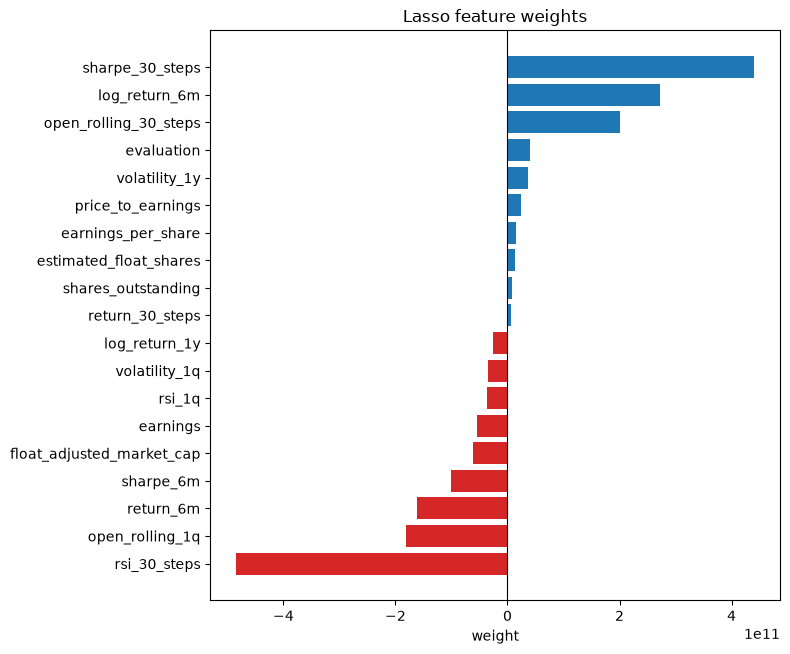

In [26]:
indicator_cols = [
    "volatility_1y",
    "volatility_1q",
    "return_6m",
    "return_30_steps",
    "log_return_6m",
    "log_return_1y",
    "rsi_1q",
    "rsi_30_steps",
    "open_rolling_30_steps",
    "open_rolling_1q",
    "sharpe_6m",
    "sharpe_30_steps",
    "shares_outstanding",
    "estimated_float_shares",
    "earnings",
    "evaluation",
    "price_to_earnings",
    "float_adjusted_market_cap",
    "earnings_per_share",
]

weights = lasso_feature_selection(
    stocks_daily.select(
        ["symbol", "timeframe"] + indicator_cols + ["future_price"]
    )
)
plot_feature_weights(weights)

# Using Spearman correlation

## All features prediction

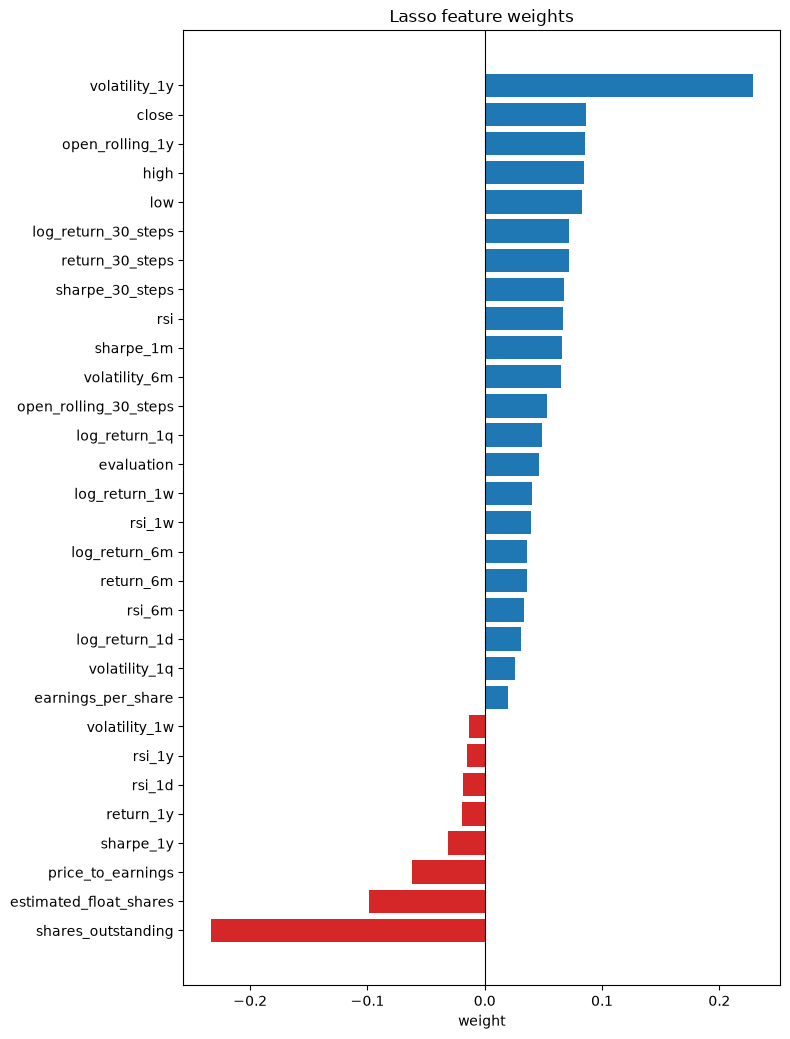

In [27]:
wights = spearman_feature_selection(stocks_daily)
plot_feature_weights(wights)

## Per-indicator time window selection

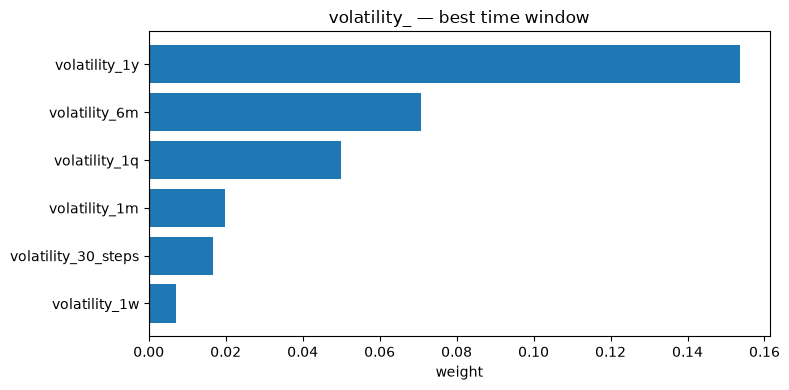

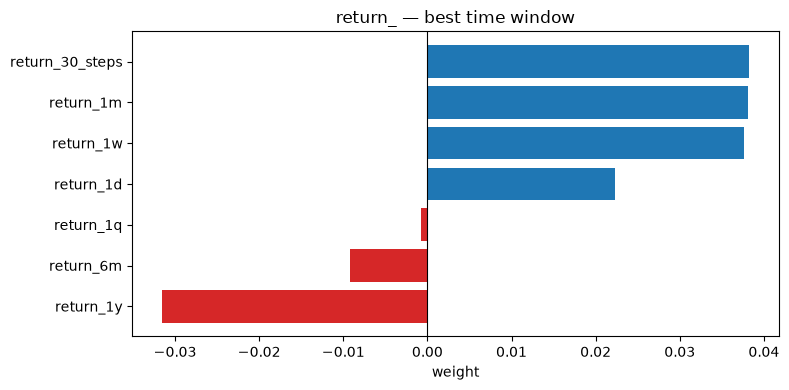

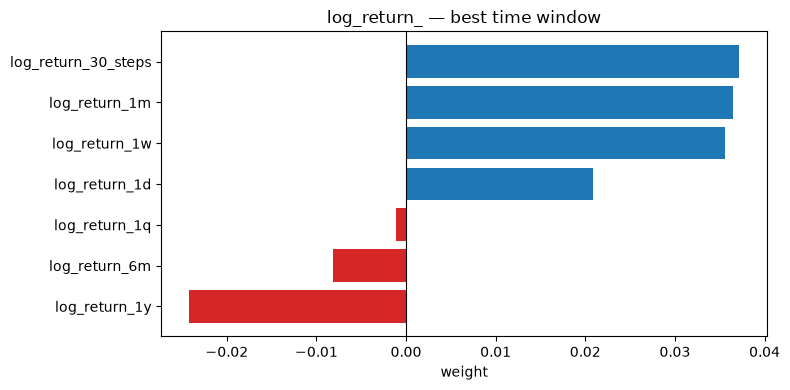

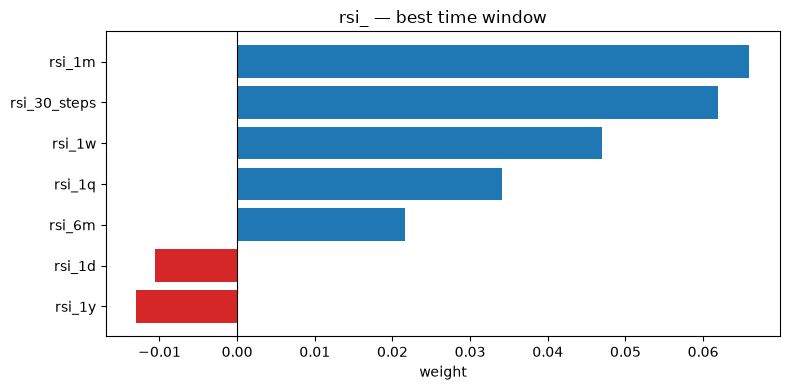

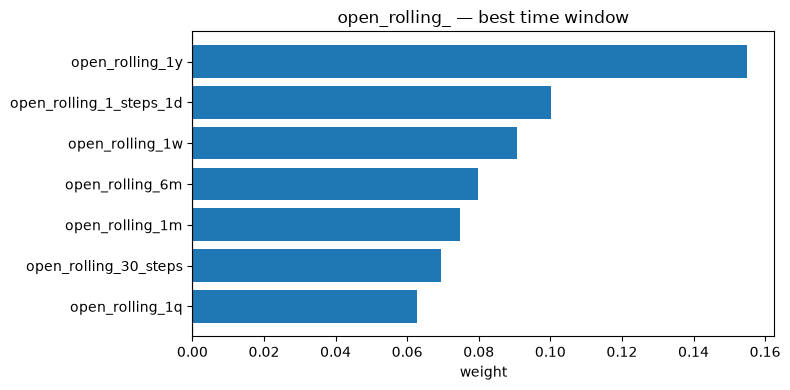

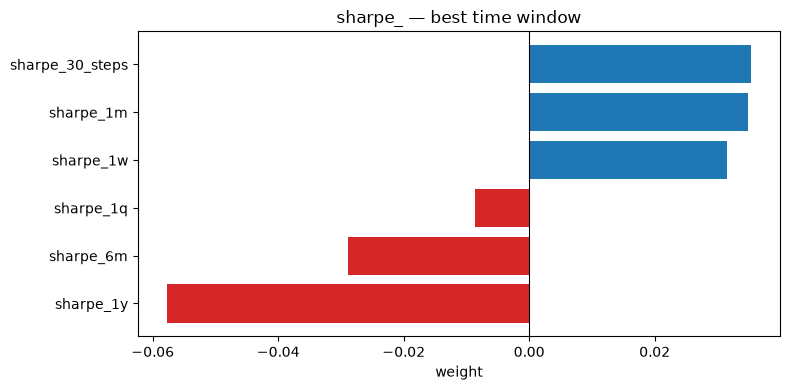

In [28]:
INDICATOR_PREFIX = [
    "volatility_",
    "return_",
    "log_return_",
    "rsi_",
    "open_rolling_",
    "sharpe_",
]

for prefix in INDICATOR_PREFIX:
    # select columns matching the prefix + the future price
    indicator_cols = [c for c in stocks_daily.columns if c.startswith(prefix)]
    subset = stocks_daily.select(["symbol", "timeframe"] + indicator_cols + ["future_price"])

    # run the same feature selection above with the selected dataframe
    weights = spearman_feature_selection(subset)
    plot_feature_weights(weights, title=f"{prefix} — best time window")

## All features again, but only with top positive and bottom negative correlators

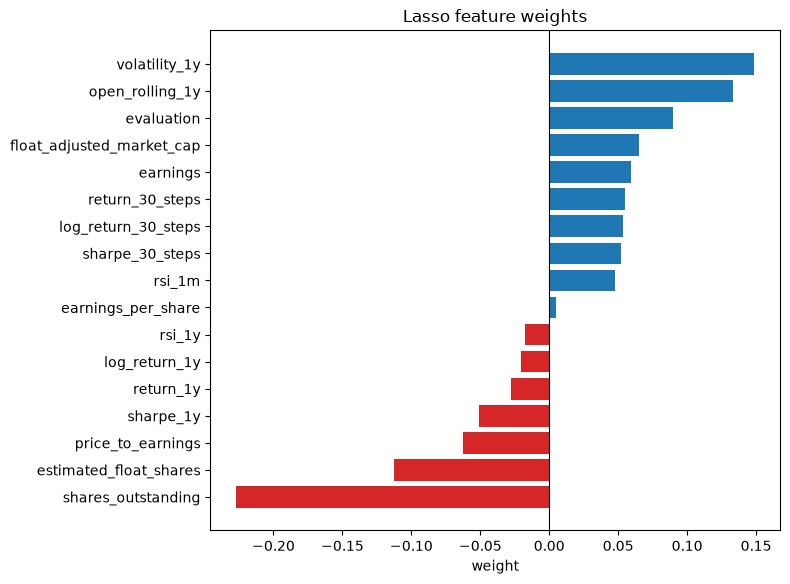

In [10]:
indicator_cols = [
    # no negative correlator for volatility
    "volatility_1y",
    "return_30_steps",
    "return_1y",
    "log_return_30_steps",
    "log_return_1y",
    "rsi_1m",
    "rsi_1y",
    # no negative correlation for open_rolling
    "open_rolling_1y",
    "sharpe_30_steps",
    "sharpe_1y",
    "shares_outstanding",
    "estimated_float_shares",
    "earnings",
    "evaluation",
    "price_to_earnings",
    "float_adjusted_market_cap",
    "earnings_per_share",
]

weights = spearman_feature_selection(
    stocks_daily.select(
        ["symbol", "timeframe"] + indicator_cols + ["future_price"]
    )
)
plot_feature_weights(weights)